# NLP Analysis of Political Manifestos

This project applies Natural Language Processing techniques to analyze political manifestos using semantic embeddings.

The goal is to measure similarity between documents and explore whether ideological proximity is reflected in textual representations.

## Dataset

This analysis is based on a subset of the Archelec corpus, focusing exclusively on French legislative elections of 1988.

The dataset consists of political manifestos, which are used to study semantic similarity across political actors.

In [52]:
!pip install pandas numpy matplotlib scikit-learn spacy sentence-transformers tqdm
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 78.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [53]:
import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import spacy
from sentence_transformers import SentenceTransformer

## Data Loading

We extract the dataset from the uploaded zip file.

In [54]:
# NOTE: dataset not included in the repository.
# Place the dataset inside the "data/" folder before running.

import zipfile

zip_path = "/content/legislatives (2).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed")


Extraction completed


In [55]:
import os
import pandas as pd

# Assicurati che questo path sia corretto
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder, filename)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        data.append({
            "id": filename,
            "text": text
        })

# Creazione DataFrame
df = pd.DataFrame(data)

# Controllo
print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL176_L_1988_06_060_06_1_PF_01.txt,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...
1,EL177_L_1988_06_095_07_1_PF_03.txt,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...
2,EL175_L_1988_06_034_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
3,EL177_L_1988_06_095_03_2_PF_01.txt,Sciences Po / fonds CEVIPOF\nElections législa...
4,EL176_L_1988_06_059_12_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...


## Preprocessing

Text data is cleaned before analysis:
- Lowercasing
- Removing punctuation
- Removing stopwords

This step ensures more meaningful embeddings.

In [56]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

## Exploratory Data Analysis

We analyse document lengths.

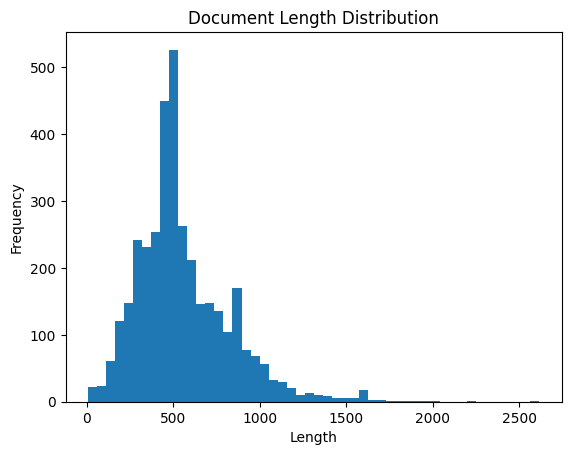

<Figure size 640x480 with 0 Axes>

In [57]:
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["length"], bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

plt.savefig("length_plot.png")

## Semantic Density

We define semantic density as the ratio of content words to total words.

In [58]:
nlp = spacy.load("fr_core_news_sm")

def semantic_density(text):
    doc = nlp(text[:1000])
    content = [t for t in doc if t.pos_ in ["NOUN","VERB","ADJ"]]
    return len(content) / len(doc) if len(doc) > 0 else 0

df["density"] = df["clean_text"].apply(semantic_density)

## Density Distribution

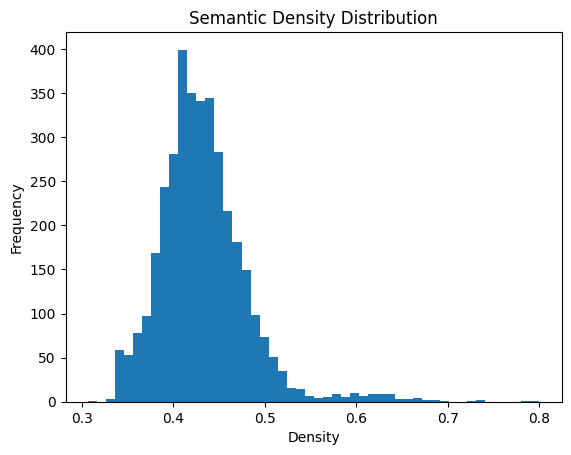

<Figure size 640x480 with 0 Axes>

In [59]:
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

plt.savefig("density_plot.png")

In [60]:
print("LOW DENSITY EXAMPLE:\n")
print(df.sort_values("density").iloc[0]["text"][:500])

print("\nHIGH DENSITY EXAMPLE:\n")
print(df.sort_values("density", ascending=False).iloc[0]["text"][:500])

LOW DENSITY EXAMPLE:

Madame, Mademoiselle, Monsieur,
Dimanche vous avez mis le Parti Socialiste en ballotage dans notre circonscription. Pourquoi ?
Parce que, comme les autres Français, vous ne voulez pas de la toute puissance d'un seul parti en France.
Parce que les Socialistes ne représentent qu'un Français sur trois. Alors que la Présidence de la République est entre leurs mains, il serait malsain que l'Assemblée Nationale leur donne 100% des pouvoirs.
Parce que les Socialistes, bien qu'ils ne représentent qu'un 

HIGH DENSITY EXAMPLE:

Département : PARIS 18ème Circonscription
Sylvie EDMONDSON suppléante Marie-José SERIZIER
PARTI OUVRIER EUROPÉEN
Sciences Po / fonds CEVIPOV


## TF-IDF Representation

We compute a lexical baseline using TF-IDF.

In [61]:
vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = vectorizer.fit_transform(df["clean_text"])

tfidf_sim = cosine_similarity(tfidf_matrix)

## Model

We use a pretrained transformer-based model (BERT) to encode documents into dense vector representations.

These embeddings capture semantic meaning beyond simple word matching, enabling comparison between documents based on context and meaning.

In [62]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

## Embedding Computation

Each document is converted into a vector representation using a pretrained model.

## Similarity Computation

We compute cosine similarity between document embeddings.

In [63]:
from sklearn.metrics.pairwise import cosine_similarity

emb_sim = cosine_similarity(embeddings)

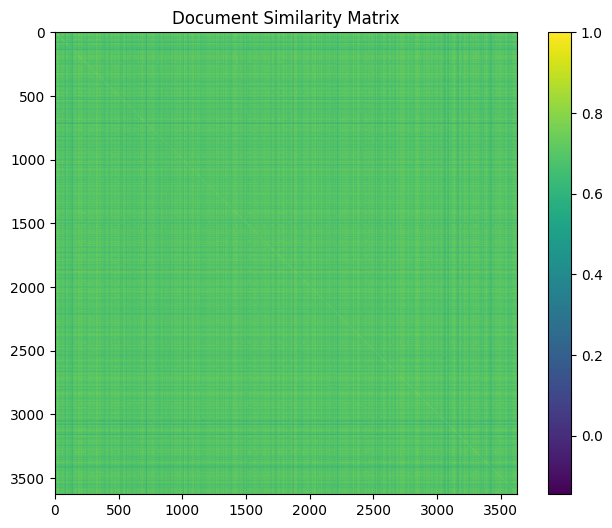

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(emb_sim, cmap='viridis')
plt.colorbar()
plt.title("Document Similarity Matrix")
plt.show()

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])
plt.title("Document Clustering (t-SNE)")
plt.show()

## Ranking Task

We retrieve the most similar documents given a query.

In [65]:
def get_top_k(sim_matrix, idx, k=5):
    scores = sim_matrix[idx]
    return scores.argsort()[::-1][1:k+1]

In [66]:
query_idx = 0

print("QUERY:\n")
print(df.iloc[query_idx]["text"][:500])

print("\nTOP 5 SIMILI:\n")

top_docs = get_top_k(emb_sim, query_idx)

for i in top_docs:
    print(f"\n--- Documento {i} ---\n")
    print(df.iloc[i]["text"][:300])

QUERY:

DEPARTEMENT DE L'OISE
6ème CIRCONSCRIPTION
COMPIÈGNE NORD
Elections Législatives du 5 juin 1988
Jacques DESMOULIN
30 ans Employé
Candidat de rassemblement des forces de gauche présenté par le Parti Communiste Français
Sciences Po / fonds CEVIPOFMadame, Monsieur,
· Le Dimanche 5 Juin vous êtes appelés à voter pour élire votre député. Pourquoi ?
· Le Président de la République l'a expliqué à la télévision. Son Gouvernement comprend trois ministres membres de l'UDF, dont M. Fauroux, ancien patron d

TOP 5 SIMILI:


--- Documento 1892 ---

DÉPARTEMENT DE L'OISE
VII CIRCONSCRIPTION : MOUY-CLERMONT ÉLECTIONS LÉGISLATIVES DU 5 JUIN 1988
JEAN SYLLA
58 ans Employé Maire de Mouy - Conseiller Général
Candidat de Rassemblement des forces de gauche présenté par le Parti Communiste Français
Sciences Po / fonds CEVIPOFMadame, Monsieur,
Le dimanc

--- Documento 577 ---

DEPARTEMENT DE L'OISE
1 ère CIRCONSCRIPTION
Elections Législatives des 5 et 12 juin 1988
Claude AURY
Maire-Adjoint de Beauvai

## Results and Interpretation

Documents that are semantically similar tend to have higher cosine similarity scores.

This suggests that embeddings capture meaningful relationships between political manifestos.

## Model Comparison

In [67]:
print("TF-IDF:", get_top_k(tfidf_sim, query_idx))
print("EMBEDDINGS:", get_top_k(emb_sim, query_idx))

TF-IDF: [ 675 2732  201 2174 1990]
EMBEDDINGS: [1892  577 2994  675  976]


## Discussion

Semantic density highlights differences in informational content.  
Embedding-based similarity captures deeper relationships than TF-IDF.  

Limitations include OCR noise and simplified linguistic assumptions.

## Limitations

- The dataset is limited to 1988 legislative elections
- No fine-tuning was performed
- Results depend on pretrained embeddings

## Conclusion

NLP techniques allow meaningful analysis of political texts, both linguistically and semantically.